# **Практическая работа №1. Основные методы OpenCV. Часть №1**

In [36]:
import cv2
from google.colab.patches import cv2_imshow
import numpy as np
import matplotlib.pyplot as plt

---

# **Тема №1. Чтение, запись и отображение**



## **Задание 1:**  
Напишите процедуру, которая:

- Считывает цветное изображение в режиме `cv2.IMREAD_COLOR`.
- Преобразует его в оттенки серого с использованием `cv2.cvtColor()`.
- Сохраняет полученное черно-белое изображение на диск.
- Отображает оба изображения (оригинальное цветное и преобразованное черно-белое).




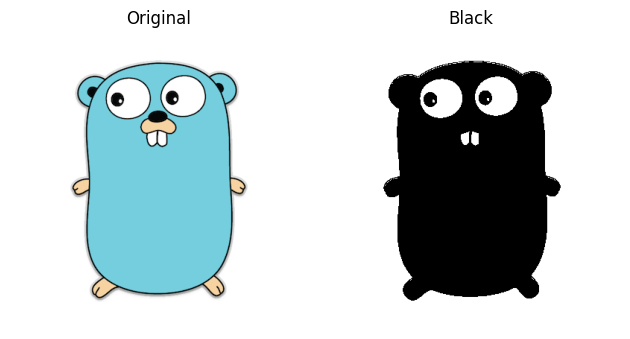

In [37]:
image_path_1 = "/content/gopher.jpg"

image_clr = cv2.imread(image_path_1, cv2.IMREAD_COLOR)

image_gray = cv2.cvtColor(image_clr, cv2.COLOR_BGR2GRAY)

image_black = image_gray.copy()
value = image_black.mean()

image_black[image_black > value] = 255
image_black[image_black <= value] = 0

cv2.imwrite("task1-image-black.jpg", image_black)

plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(cv2.cvtColor(image_clr, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Black")
plt.imshow(image_black, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()

## **Задание 2:**  
Используя режим `cv2.IMREAD_UNCHANGED`, загрузите изображение с альфа-каналом (например, PNG с прозрачностью). Затем:

- Разделите изображение на каналы (B, G, R, A).
- Создайте новое изображение, где прозрачность (альфа-канал) инвертирована (т.е. прозрачные области становятся непрозрачными и наоборот).
- Сохраните и отобразите полученное изображение.

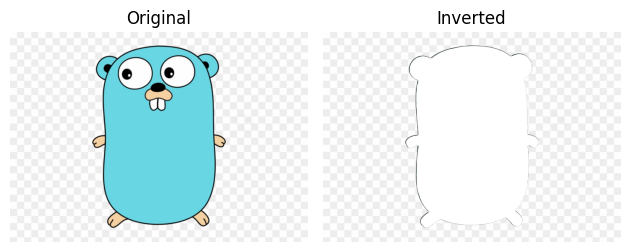

In [38]:
image_path_2 = "/content/alpha-gopher.png"

image_unchanged = cv2.imread(image_path_2, cv2.IMREAD_UNCHANGED)

b, g, r, a = cv2.split(image_unchanged)

a_inverted = 255 - a

image_inverted = cv2.merge((r, g, b, a_inverted))

cv2.imwrite("alpha-gopher-inverted.png", image_inverted)

plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(cv2.cvtColor(image_unchanged, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Inverted")
plt.imshow(image_inverted, )
plt.axis("off")

plt.tight_layout()
plt.show()

---

# **Тема №2. Работа с цветовыми палитрами**



## **Задание 3:**  
Напишите процедуру, которая:

- Считывает цветное изображение.
- Преобразует его из цветового пространства BGR в HSV с помощью `cv2.cvtColor()`.
- Увеличивает насыщенность (канал S) в 1.5 раза, не превышая максимального значения.
- Преобразует изображение обратно в цветовое пространство BGR.
- Отображает оригинальное и полученное изображения рядом для сравнения.

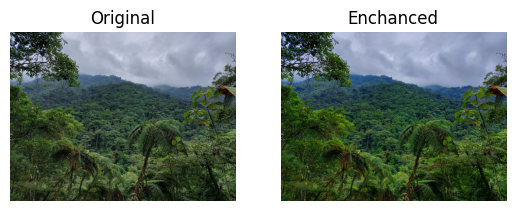

In [39]:
image_path_3 = "/content/forest.jpg"

image_3 = cv2.imread(image_path_3, cv2.IMREAD_COLOR)

image_hsv = cv2.cvtColor(image_3, cv2.COLOR_BGR2HSV)
image_hsv[:, :, 1] = cv2.min(image_hsv[:, :, 1]*1.5, 255)

image_enchanced = cv2.cvtColor(image_hsv, cv2.COLOR_HSV2BGR)

plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(cv2.cvtColor(image_3, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Enchanced")
plt.imshow(cv2.cvtColor(image_enchanced, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.show()

## **Задание 4:**  
Напишите процедуру, которая:

- Считывает изображение и Преобразует его в цветовое пространство YCrCb.
- Применяет размытие к компоненте яркости Y (при помощи фильтра, см. материал предыдущих занятий).
- Снова Преобразует изображение в цветовое пространство BGR.
- Отображает исходное и размытое изображения.

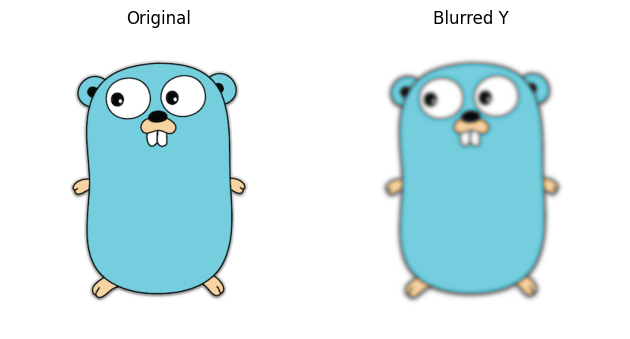

In [40]:
image_ycrcb = cv2.cvtColor(image_clr, cv2.COLOR_BGR2YCrCb)

y, cr, cb = cv2.split(image_ycrcb)

y_blurred = cv2.GaussianBlur(y, (15, 15), 0)

image_ycrcb_blurred = cv2.merge((y_blurred, cr, cb))

image_blurred = cv2.cvtColor(image_ycrcb_blurred, cv2.COLOR_YCrCb2BGR)

plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(cv2.cvtColor(image_clr, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Blurred Y")
plt.imshow(cv2.cvtColor(image_blurred, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.tight_layout()
plt.show()


---

# **Тема №3. Слияние и усиление**

## **Задание 5:**  
Создайте процедуру, которая:

- Считывает два изображения одинакового размера (можно подкорректировать с помощью метода `.resize()`).
- Выполняет побитовое ИЛИ (OR) над соответствующими пикселями двух изображений.
- Сохраняет и отображает результат операции.

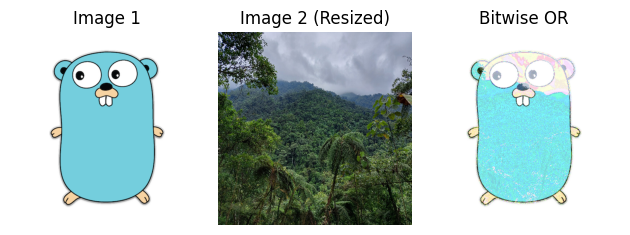

In [41]:
img_1 = cv2.imread('/content/gopher.jpg', cv2.IMREAD_COLOR)
img_2 = cv2.imread('/content/forest.jpg', cv2.IMREAD_COLOR)

h, w = img_1.shape[:2]
img_2_resize = cv2.resize(img_2, (w, h))

image_or = cv2.bitwise_or(img_1, img_2_resize)
cv2.imwrite('bit.jpg', image_or)

plt.subplot(1, 3, 1)
plt.title("Image 1")
plt.imshow(cv2.cvtColor(img_1, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Image 2 (Resized)")
plt.imshow(cv2.cvtColor(img_2_resize, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Bitwise OR")
plt.imshow(cv2.cvtColor(image_or, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.tight_layout()
plt.show()

## **Задание 6:**  
Реализуйте следующий алгоритм:

- Считайте цветное изображение и разделите его на три канала с использованием `.split()`.
- Примените к каждому каналу разный коэффициент гамма-коррекции (например, для R – 0.5, G – 1.0, B – 1.5).
- Объедините каналы обратно с помощью `.merge()`.
- Отобразите исходное и обработанное изображения.


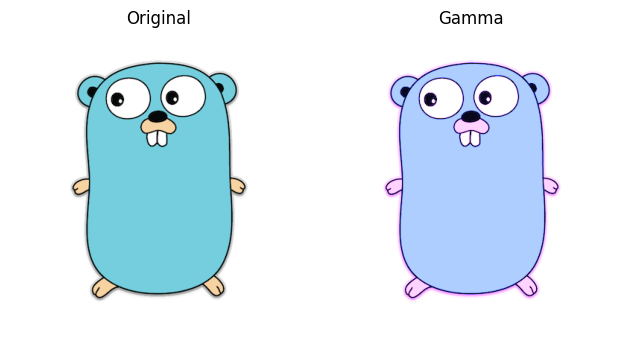

In [42]:
b, g, r = cv2.split(image_clr)

r_gamma_cor = cv2.multiply(r, 1.5)
g_gamma_cor = cv2.multiply(g, 1.0)
b_gamma_cor = cv2.multiply(b, 3.5)

image_gamma_cor = cv2.merge([b_gamma_cor, g_gamma_cor, r_gamma_cor])

plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(cv2.cvtColor(image_clr, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Gamma")
plt.imshow(cv2.cvtColor(image_gamma_cor, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.tight_layout()
plt.show()

---

# **Тема №4. Работа с гистограммами в OpenCV**

## **Задание 7:**  
Напишите процедуру для улучшения контрастности изображения:

- Считывает изображение в оттенках серого.
- Строит его гистограмму с использованием `cv.calcHist()`.
- Применяет эквализацию гистограммы методом `cv2.equalizeHist()`.
- Отображает на одном графике исходное и эквализованное изображения вместе с их гистограммами.

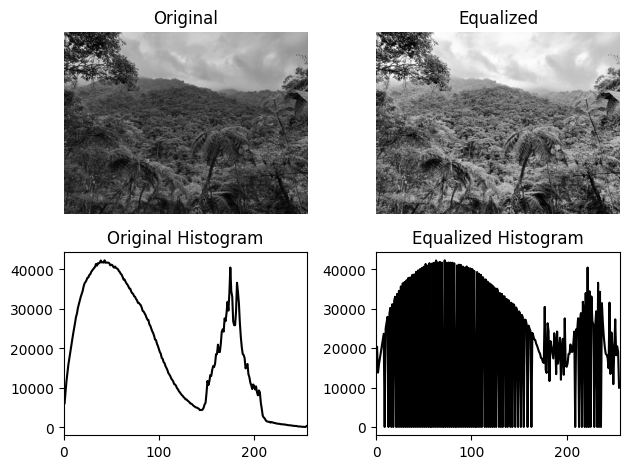

In [43]:
image_gray = cv2.imread(image_path_3, cv2.IMREAD_GRAYSCALE)

hist_orig = cv2.calcHist([image_gray], [0], None, [256], [0, 256])
image_equalized = cv2.equalizeHist(image_gray)

hist_eq = cv2.calcHist([image_equalized], [0], None, [256], [0, 256])
cv2.imwrite("task7-equalized.jpg", image_equalized)


plt.subplot(2, 2, 1)
plt.title("Original")
plt.imshow(image_gray, cmap="gray")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.title("Equalized")
plt.imshow(image_equalized, cmap="gray")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.title("Original Histogram")
plt.plot(hist_orig, color="black")
plt.xlim([0, 256])

plt.subplot(2, 2, 4)
plt.title("Equalized Histogram")
plt.plot(hist_eq, color="black")
plt.xlim([0, 256])

plt.tight_layout()
plt.show()

## **Задание 8:**  
Используйте метод CLAHE для улучшения деталей в затемненных областях цветного изображения:

- Преобразуйте изображение из BGR в LAB цветовое пространство.
- Разделите изображение на каналы и примените `cv2.createCLAHE()` к каналу яркости L.
- Объедините обработанный канал L с исходными каналами A и B.
- Преобразуйте изображение обратно в BGR.
- Отобразите исходное и обработанное изображения для сравнения вместе с их гистограммами.

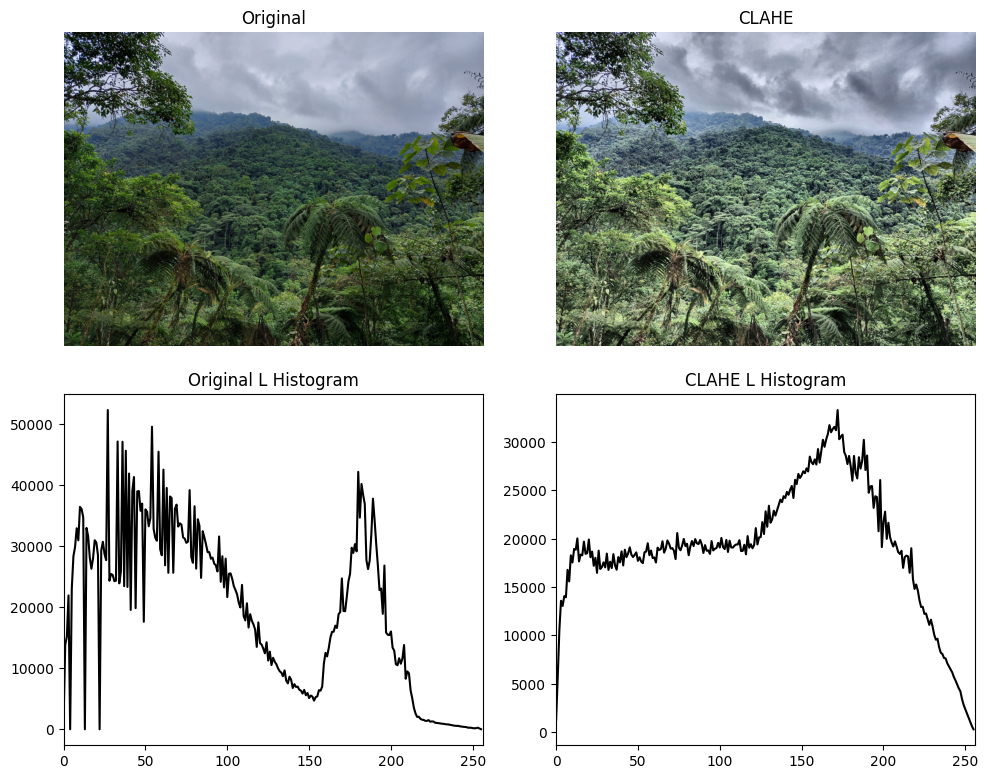

In [48]:
image_8 = cv2.imread(image_path_3, cv2.IMREAD_COLOR)

image_lab = cv2.cvtColor(image_8, cv2.COLOR_BGR2LAB)

l, a, b = cv2.split(image_lab)

hist_orig = cv2.calcHist([l], [0], None, [256], [0, 256])

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
l_clahe = clahe.apply(l)

hist_clahe = cv2.calcHist([l_clahe], [0], None, [256], [0, 256])

image_lab_clahe = cv2.merge((l_clahe, a, b))

image_clahe = cv2.cvtColor(image_lab_clahe, cv2.COLOR_LAB2BGR)

cv2.imwrite("task8-clahe.jpg", image_clahe)

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.title("Original")
plt.imshow(cv2.cvtColor(image_8, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(2, 2, 2)
plt.title("CLAHE")
plt.imshow(cv2.cvtColor(image_clahe, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(2, 2, 3)
plt.title("Original L Histogram")
plt.plot(hist_orig, color="black")
plt.xlim([0, 256])

plt.subplot(2, 2, 4)
plt.title("CLAHE L Histogram")
plt.plot(hist_clahe, color="black")
plt.xlim([0, 256])

plt.tight_layout()
plt.show()

## **Затем:**  
Исследуйте влияние размера окна (tileGridSize) и порога по сравнению с гистограммой (clipLimit) в методе CLAHE на конечный результат. Попробуйте несколько различных значений и визуализируйте результаты.


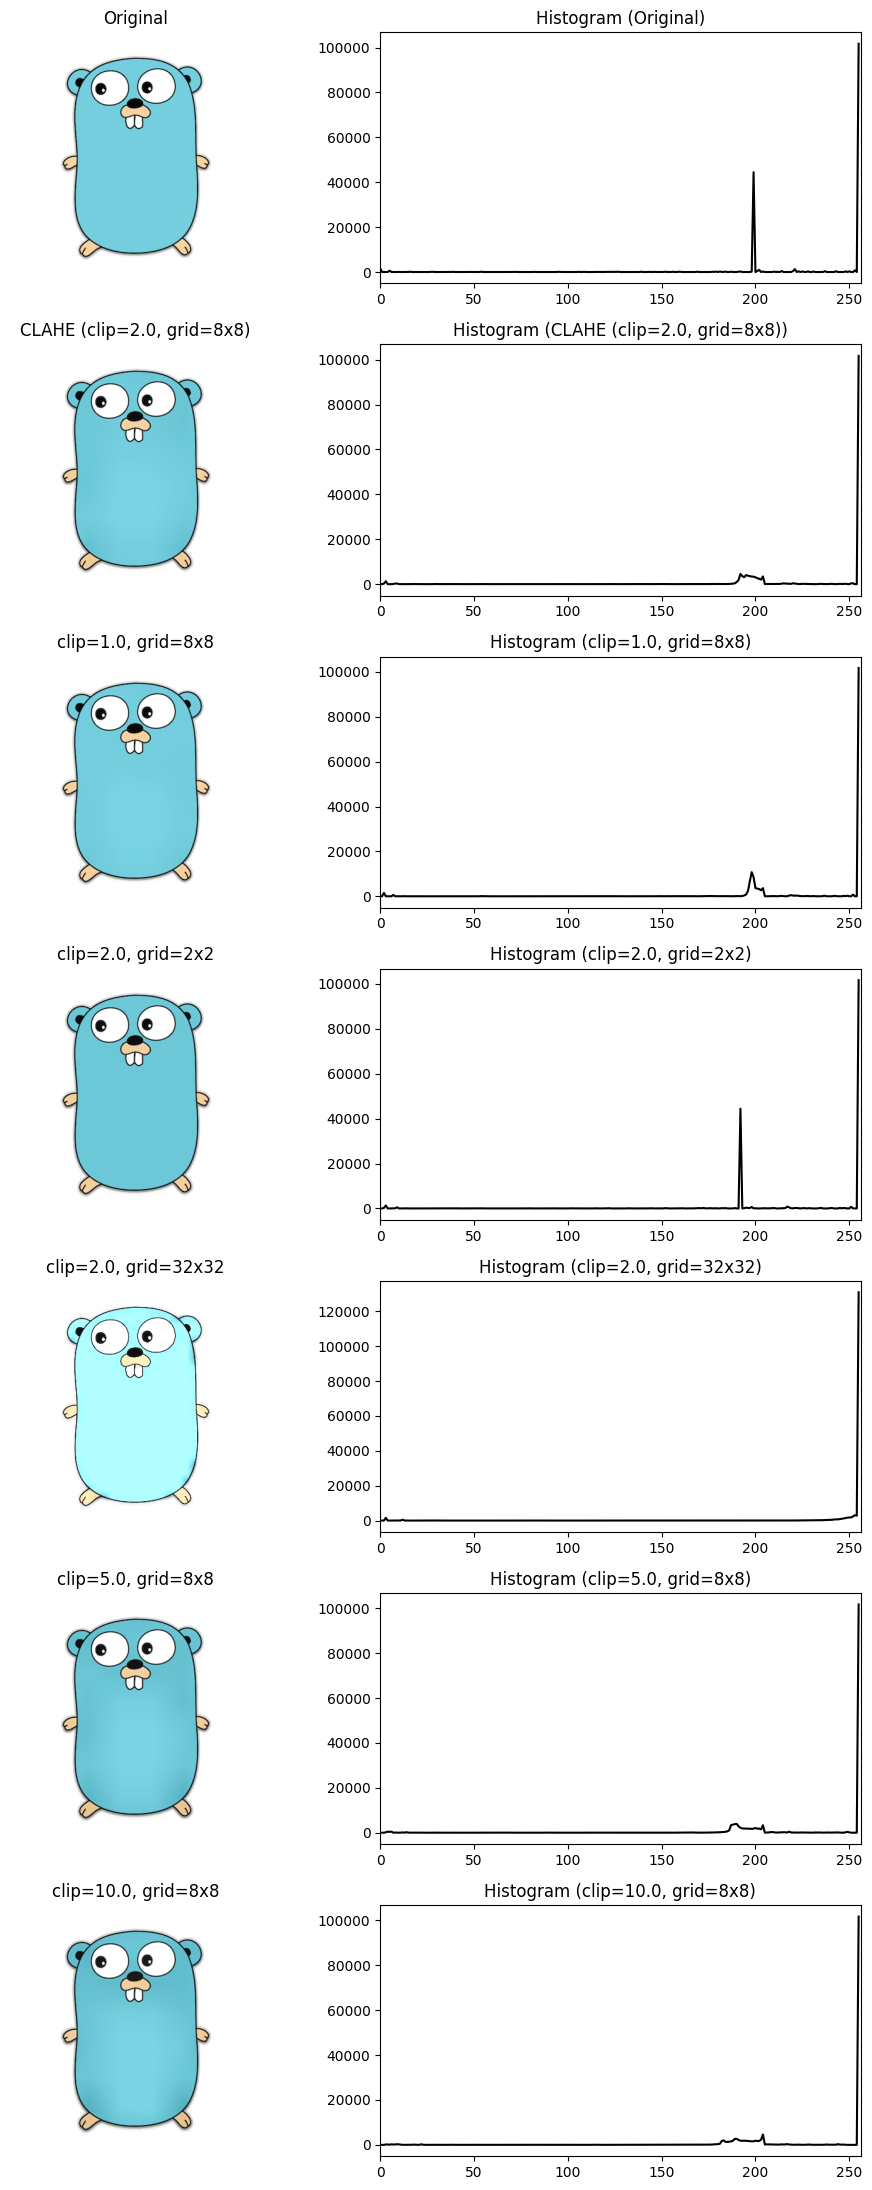

In [45]:
params = [
    ("Original", None, None),
    ("CLAHE (clip=2.0, grid=8x8)", 2.0, (8, 8)),
    ("clip=1.0, grid=8x8", 1.0, (8, 8)),
    ("clip=2.0, grid=2x2", 2.0, (2, 2)),
    ("clip=2.0, grid=32x32", 2.0, (32, 32)),
    ("clip=5.0, grid=8x8", 5.0, (8, 8)),
    ("clip=10.0, grid=8x8", 10.0, (8, 8))
]

plt.figure(figsize=(10, 22))

for idx, (title, clip, grid) in enumerate(params, start=1):
    if clip is None:
        l_curr = l
        bgr_curr = image_8
    else:
        clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=grid)
        l_curr = clahe.apply(l)
        lab_curr = cv2.merge((l_curr, a, b))
        bgr_curr = cv2.cvtColor(lab_curr, cv2.COLOR_LAB2BGR)

    hist_curr = cv2.calcHist([l_curr], [0], None, [256], [0, 256])

    plt.subplot(len(params), 2, (idx - 1) * 2 + 1)
    plt.title(title)
    plt.imshow(cv2.cvtColor(bgr_curr, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.subplot(len(params), 2, (idx - 1) * 2 + 2)
    plt.title(f"Histogram ({title})")
    plt.plot(hist_curr, color="black")
    plt.xlim([0, 256])

plt.tight_layout()
plt.show()

---

# **Комплексное задание №1. Улучшение качества отсканированного документа с использованием OpenCV**



## **Краткое описание задания:**

- Необходимо написать функцию для улучшения качества отсканированного документа с использованием методов обработки изображений, изученных ранее. Функция должна принимать на вход изображение отсканированного документа и возвращать его улучшенную версию, готовую для дальнейшего использования, например, для распознавания текста.

Датасет с отсканированными изображениями можно найти в сети Интернет.

---



## **Алгоритм действий:**

#### **Реализуйте функцию на языке Python с использованием библиотеки OpenCV, которая выполняет следующие этапы обработки:**

### **1. Чтение, запись и отображение изображений:**

- Функция должна принимать на вход изображение отсканированного документа (например, в формате JPEG или PNG)
- Проверьте наличие альфа-канала в изображении и, если он присутствует, загрузите изображение в режиме `cv2.IMREAD_UNCHANGED`, иначе используйте `cv2.IMREAD_COLOR`
- Отобразите исходное изображение для визуальной проверки

### **2. Работа с цветовыми палитрами:**

- Преобразуйте изображение в оттенки серого, используя `cv2.cvtColor()` с параметром `cv2.COLOR_BGR2GRAY`.
- Отобразите полученное изображение в оттенках серого.

### **3. Слияние и усиление:**

- Примените медианный фильтр (`cv2.medianBlur()`) для удаления шумов с изображения. Выберите подходящий размер ядра (например, 3 или 5). Отобразите результат.
- Используйте фильтр сглаживания с применением прямой свертки (`cv2.filter2D()`) с заданным ядром для повышения четкости. Например, можно использовать фильтр "Unsharp Masking":
  - Создайте ядро для повышения резкости. Пример ядра:
    ```python
    kernel = np.array([[-1, -1, -1],
                       [-1,  9, -1],
                       [-1, -1, -1]])
    ```
  - Примените фильтр к изображению и отобразите результат.

### **4. Работа с гистограммами:**

- Примените метод CLAHE (Contrast Limited Adaptive Histogram Equalization) для улучшения контрастности изображения:
  - Создайте объект CLAHE с параметрами `clipLimit=2.0` и `tileGridSize=(8,8)`.
  - Примените CLAHE к изображению.
  - отобразите результат.
- Постройте гистограммы яркости исходного и обработанного изображений для сравнения.

---

### **Требования к функции:**

- Функция должна называться: `improve_scan(image)`, где `image` — входное изображение в виде массива NumPy.
- Функция должна возвращать улучшенное изображение в виде массива NumPy.
- В ходе работы функция должна **опционально** отображать промежуточные результаты для наглядности (в условиях Colab использовать соответствующие методы вывода изображений). Для этого следует ввести отдельный параметр (например: `visible=True`) и реализовать с ним соответствующую логику.

---

### **Дополнительные требования:**

- **Обработка ошибок:**
  - Убедитесь, что функция корректно обрабатывает ситуации, когда на вход подается некорректное изображение.
  - Добавьте проверки на тип входных данных.

- **Документация и комментарии:**
  - Функция должна быть снабжена понятной документацией: опишите, какие преобраования выполняются и для чего.
  - Добавьте комментарии к основным участкам кода для пояснения выполняемых действий.



---

### **Подсказки и рекомендации:**


- **Медианный фильтр:**
  Функция `cv2.medianBlur(src, ksize)` принимает на вход изображение и размер ядра (должен быть нечетным числом).

- **CLAHE:**
  - Создайте объект CLAHE с помощью `cv2.createCLAHE(clipLimit, tileGridSize)`.
  - Примените метод `apply()` к изображению в оттенках серого.

- **Отображение изображений в Google Colab:**
  - Используйте `matplotlib.pyplot` для отображения изображений.
  - Помните, что `cv2.imread()` загружает изображения в формате BGR, поэтому для корректного отображения в Matplotlib Преобразуйте изображение в RGB с помощью `cv2.cvtColor(image, cv2.COLOR_BGR2RGB)`.

---

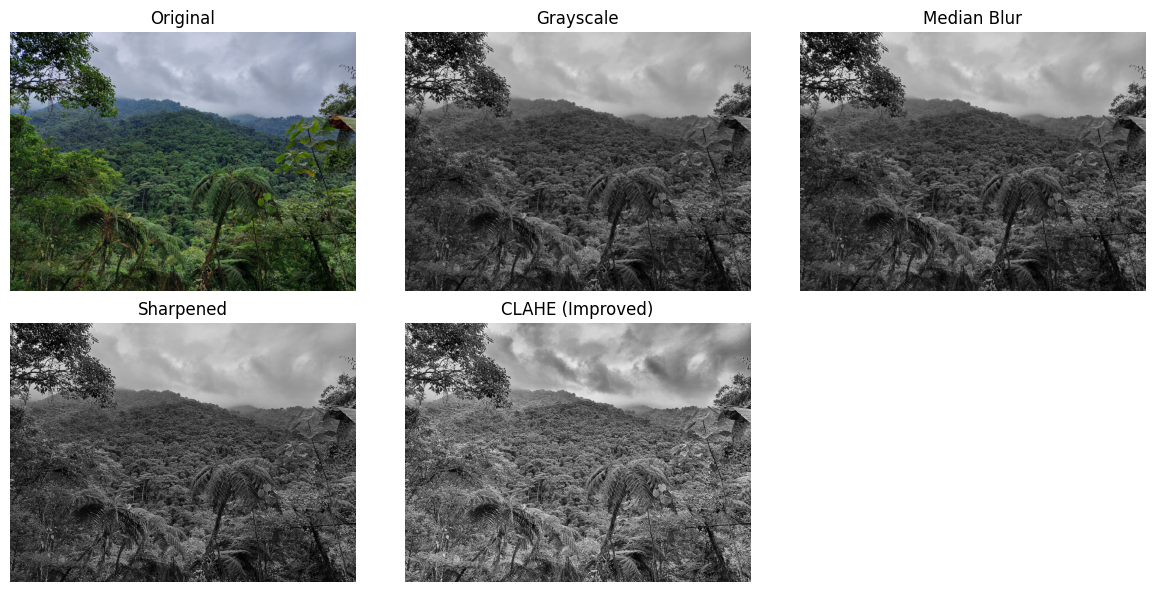

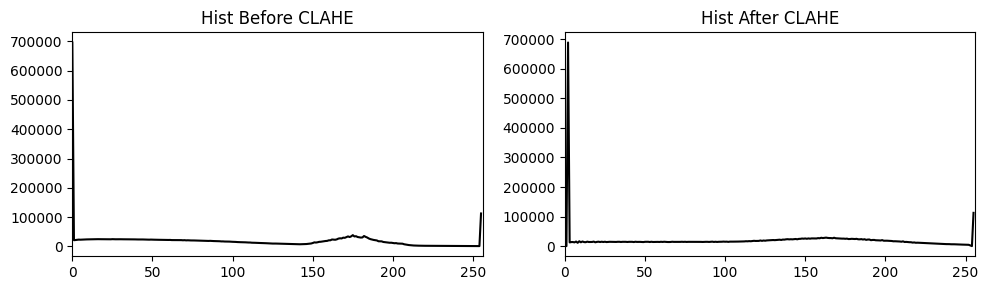

In [65]:
def improve_scan(image, visible=True):
    if isinstance(image, str):
        image = cv2.imread(image, cv2.IMREAD_UNCHANGED)

    if image is None:
        print("Ошибка загрузки изображения")
        return

    if image.ndim == 2:
        image_gray = image.copy()
    elif image.shape[2] == 4:
        image_gray = cv2.cvtColor(image, cv2.COLOR_BGRA2GRAY)
    else:
        image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    image_denoised = cv2.medianBlur(image_gray, 3)

    kernel = np.array([[-1, -1, -1],
                       [-1,  9, -1],
                       [-1, -1, -1]])
    image_sharpened = cv2.filter2D(image_denoised, -1, kernel)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    image_improved = clahe.apply(image_sharpened)


    if visible:
        plt.figure(figsize=(12, 6))

        plt.subplot(2, 3, 1)
        plt.title("Original")
        if image.ndim == 2:
            plt.imshow(image, cmap="gray")
        elif image.shape[2] == 4:
            plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGRA2RGBA))
        else:
            plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.axis("off")

        plt.subplot(2, 3, 2)
        plt.title("Grayscale")
        plt.imshow(image_gray, cmap="gray")
        plt.axis("off")

        plt.subplot(2, 3, 3)
        plt.title("Median Blur")
        plt.imshow(image_denoised, cmap="gray")
        plt.axis("off")

        plt.subplot(2, 3, 4)
        plt.title("Sharpened")
        plt.imshow(image_sharpened, cmap="gray")
        plt.axis("off")

        plt.subplot(2, 3, 5)
        plt.title("CLAHE (Improved)")
        plt.imshow(image_improved, cmap="gray")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

        hist_before = cv2.calcHist([image_sharpened], [0], None, [256], [0, 256])
        hist_after = cv2.calcHist([image_improved], [0], None, [256], [0, 256])

        plt.figure(figsize=(10, 3))

        plt.subplot(1, 2, 1)
        plt.title("Hist Before CLAHE")
        plt.plot(hist_before, color="black")
        plt.xlim([0, 256])

        plt.subplot(1, 2, 2)
        plt.title("Hist After CLAHE")
        plt.plot(hist_after, color="black")
        plt.xlim([0, 256])

        plt.tight_layout()
        plt.show()

    return image_improved


path = "/content/forest.jpg"
scan = cv2.imread(path, cv2.IMREAD_UNCHANGED)
result = improve_scan(scan, visible=True)

## **Дополнительное задание:**

- Поэкспериментируйте с параметрами медианного фильтра, ядром для фильтра повышения резкости и параметрами CLAHE для достижения наилучшего результата.
- Добавьте возможность передачи этих параметров в функцию `improve_scan` для более гибкой настройки обработки. **В качестве параметров по умолчанию установите те, которые показали себя лучше всего по результатам экспериментов**

**Пример с параметрами:**

```python
def improve_scan(image,
                 median_kernel_size=3,
                 sharp_kernel= np.array([[-1, -1, -1],
                                         [-1,  9, -1],
                                         [-1, -1, -1]]),
                 clahe_clip=2.0,
                 clahe_grid=(8,8),
                 visible=True):
    # Реализация с учетом переданных параметров
    ...
```


In [47]:
# Ваш код